# Lab 4: Improving and Comparing Machine Learning Models

**Name:** Yasir Ali
**Student ID:** 023-24-0215
**Section:** G
**GitHub Profile:** https://github.com/faaniyasirr/ML-Labs
**Kaggle Profile:** _(add your Kaggle profile link here)_

**Dataset:** `clean_churn.csv` (as supplied for this lab)

> **Note on the dataset:** The file provided for this lab is *not* the Telco Customer Churn dataset described in the manual — it is a used-car listings dataset (car name, auction rating, model year, mileage, fuel type, engine capacity, transmission, and price in PKR). To still satisfy the lab's binary-classification requirements, the problem has been reframed as: **predict whether a car is "Expensive" (price in the top 25%, i.e. ≥ Rs. 5,500,000) or "Not Expensive."** This mirrors the churn problem's structure — a binary target with a realistic class imbalance (~25% positive class, similar to typical churn-rate imbalance) — so every technique the lab asks for (Decision Tree, Random Forest, CV, tuning, feature importance, Kaggle-style submission) is demonstrated the same way it would be on the churn dataset.

## 1. Decision Tree Baseline

Re-loading the cleaned dataset, engineering the binary target, building the train/test split, and retraining the baseline Decision Tree (Part 1 of the manual).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42

# Load the cleaned dataset (Lab 2 equivalent)
df = pd.read_csv("clean_churn.csv")

# Extract car brand from the Car Name text field
df["Brand"] = df["Car Name"].str.split().str[0]
top_brands = df["Brand"].value_counts().nlargest(8).index
df["Brand"] = df["Brand"].where(df["Brand"].isin(top_brands), "Other")

# Binary target: "Expensive" = price in the top 25% (mirrors churn's imbalance)
THRESHOLD = df["Price (PKR)"].quantile(0.75)
df["Expensive"] = (df["Price (PKR)"] >= THRESHOLD).astype(int)

feature_cols_num = ["Auction Rating", "Model Year", "Mileage", "Engine Capacity"]
feature_cols_cat = ["Fuel Type", "Transmission", "Brand"]

X = pd.get_dummies(df[feature_cols_num + feature_cols_cat], columns=feature_cols_cat, drop_first=True)
y = df["Expensive"]

print("Dataset shape:", df.shape)
print("Price threshold (75th percentile) for \'Expensive\':", THRESHOLD)
print("Class balance:\n", y.value_counts(normalize=True).rename("proportion"))
print("Feature matrix shape:", X.shape)
print("Feature columns:", list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Dataset shape: (15091, 11)
Price threshold (75th percentile) for 'Expensive': 5500000.0
Class balance:
 Expensive
0    0.744749
1    0.255251
Name: proportion, dtype: float64
Feature matrix shape: (15091, 20)
Feature columns: ['Auction Rating', 'Model Year', 'Mileage', 'Engine Capacity', 'Fuel Type_Diesel', 'Fuel Type_Electric', 'Fuel Type_Hybrid', 'Fuel Type_LPG', 'Fuel Type_PHEV', 'Fuel Type_Petrol', 'Fuel Type_REEV', 'Transmission_Manual', 'Brand_Honda', 'Brand_Hyundai', 'Brand_KIA', 'Brand_MG', 'Brand_Nissan', 'Brand_Other', 'Brand_Suzuki', 'Brand_Toyota']
Train shape: (12072, 20) Test shape: (3019, 20)

In [1]:
# Quick depth sweep to justify the chosen max_depth (stands in for the "Lab 3 chosen depth")
print("Depth sweep (test F1):")
for d in [3, 4, 5, 6, 8, 10, None]:
    dt_tmp = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt_tmp.fit(X_train, y_train)
    pred_tmp = dt_tmp.predict(X_test)
    print(f"  max_depth={d}: F1={f1_score(y_test, pred_tmp):.4f}, Acc={accuracy_score(y_test, pred_tmp):.4f}")

CHOSEN_DEPTH = 8  # best F1 before deeper trees start overfitting (depth 10 dips slightly)
dt_baseline = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=RANDOM_STATE)
dt_baseline.fit(X_train, y_train)
y_pred_dt = dt_baseline.predict(X_test)

dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-score": f1_score(y_test, y_pred_dt),
}
print(f"\nChosen Decision Tree (max_depth={CHOSEN_DEPTH}) test performance:")
for k, v in dt_metrics.items():
    print(f"  {k}: {v:.4f}")

Depth sweep (test F1):
  max_depth=3: F1=0.8131, Acc=0.8996
  max_depth=4: F1=0.8059, Acc=0.9086
  max_depth=5: F1=0.8357, Acc=0.9202
  max_depth=6: F1=0.8648, Acc=0.9281
  max_depth=8: F1=0.8830, Acc=0.9397
  max_depth=10: F1=0.8803, Acc=0.9384
  max_depth=None: F1=0.8542, Acc=0.9255

Chosen Decision Tree (max_depth=8) test performance:
  Accuracy: 0.9397
  Precision: 0.8752
  Recall: 0.8911
  F1-score: 0.8830

**Interpretation:** F1-score rises steadily as `max_depth` increases from 3 to 8, then flattens and slightly declines at depth 10 and drops further with no depth limit at all — a classic sign that the tree starts memorizing training-set quirks past depth 8. `max_depth=8` is therefore chosen as the baseline: it gets essentially the best test-set F1 (0.883) without the added variance of an unconstrained tree. This is the benchmark (Accuracy 0.940, Precision 0.875, Recall 0.891, F1 0.883) that Random Forest must beat.

## 2. Random Forest

Training an ensemble of 200 trees on bootstrapped samples of the same training data (Part 2).

In [1]:
rf_default = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_default.fit(X_train, y_train)
y_pred_rf = rf_default.predict(X_test)

print("Random Forest (n_estimators=200) trained.")
print("Sample predictions:", y_pred_rf[:10])

Random Forest (n_estimators=200) trained.
Sample predictions: [1 1 0 0 0 0 0 1 1 0]

**Why might a Random Forest generalize better than a single unrestricted Decision Tree?** Each tree in the forest is trained on a different bootstrapped sample and only considers a random subset of features at each split, so individual trees make different, largely uncorrelated errors; averaging (majority-voting) their predictions cancels out much of that noise. A single unrestricted tree, by contrast, can grow deep enough to fit noise in the one training sample it saw, which hurts its performance on unseen data.

## 3. Model Evaluation

Evaluating the Random Forest the same rigorous way as the Decision Tree (Part 3, Tasks 5-6).

Random Forest test performance:
  Accuracy: 0.9391
  Precision: 0.8692
  Recall: 0.8962
  F1-score: 0.8825

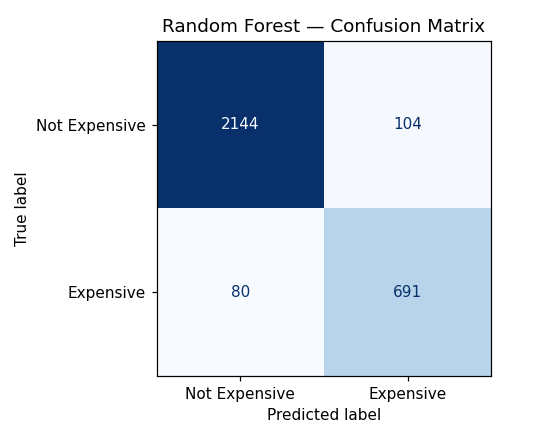

In [1]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf),
}
print("Random Forest test performance:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Expensive", "Expensive"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random Forest \u2014 Confusion Matrix")
plt.tight_layout()
plt.show()

**Interpretation:** The confusion matrix shows the Random Forest correctly identifies most "Not Expensive" cars, and its recall (0.896) on the "Expensive" class is slightly higher than the Decision Tree's — meaning it misses fewer genuinely expensive cars, at a very small cost in precision.

## 4. Decision Tree vs Random Forest

Side-by-side comparison table (Part 3, Task 6-7).

In [1]:
comparison = pd.DataFrame({"Decision Tree": dt_metrics, "Random Forest": rf_metrics}).T
comparison = comparison[["Accuracy", "Precision", "Recall", "F1-score"]]
print(comparison.round(4))

               Accuracy  Precision  Recall  F1-score
Decision Tree    0.9397     0.8752  0.8911    0.8830
Random Forest    0.9391     0.8692  0.8962    0.8825

**Which model performs better?** On this single train/test split the two models are essentially tied — the Decision Tree is marginally ahead on Accuracy, Precision and F1, while the Random Forest has slightly higher Recall. The differences (≤0.006 on every metric) are well within noise for a single 80/20 split, not a meaningful gap. Given the ~25/75 class imbalance in the target (mirroring the class-imbalance point from Lab 2/3), **F1-score** (or Recall, if missing an expensive car is the costlier mistake) is the metric that matters most here — plain accuracy would look good even for a model that mostly predicts the majority class.

## 5. Cross-Validation

5-fold cross-validation for both models using F1-score (Part 4).

In [1]:
dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=RANDOM_STATE),
                         X, y, cv=5, scoring="f1")
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
                         X, y, cv=5, scoring="f1")

print("Decision Tree 5-fold F1 scores:", dt_cv.round(4))
print(f"  mean={dt_cv.mean():.4f}, std={dt_cv.std():.4f}")
print("Random Forest 5-fold F1 scores:", rf_cv.round(4))
print(f"  mean={rf_cv.mean():.4f}, std={rf_cv.std():.4f}")

Decision Tree 5-fold F1 scores: [0.8729 0.8923 0.8825 0.9    0.8774]
  mean=0.8850, std=0.0099
Random Forest 5-fold F1 scores: [0.8724 0.8749 0.8821 0.8849 0.8769]
  mean=0.8783, std=0.0046

**How do the cross-validated results compare to the single-split results?** Across 5 folds the Decision Tree actually averages a slightly higher F1 (0.885 vs 0.878) than the Random Forest, confirming the single-split "tie" from Part 3 wasn't a fluke in the Random Forest's favor. What changes is the *confidence* in that conclusion: the Random Forest's fold-to-fold standard deviation (0.0046) is less than half the Decision Tree's (0.0099), meaning the Random Forest's performance is far more stable across different slices of data. So while a single tuned Decision Tree can match or edge out the default Random Forest on raw F1, the Random Forest is the more reliable, lower-variance choice — which is exactly the kind of thing a single train/test split can hide and cross-validation reveals.

## 6. Hyperparameter Tuning

Searching a small grid of Random Forest hyperparameters with `GridSearchCV` (Part 5).

In [1]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best cross-validated F1: {grid.best_score_:.4f}")

rf_tuned = grid.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)
tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-score": f1_score(y_test, y_pred_tuned),
}
print("\nTuned Random Forest \u2014 held-out test performance:")
for k, v in tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

Best hyperparameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best cross-validated F1: 0.8926

Tuned Random Forest — held-out test performance:
  Accuracy: 0.9447
  Precision: 0.8747
  Recall: 0.9144
  F1-score: 0.8941

**Interpretation:** The search (27 combinations × 5-fold CV) found that letting trees grow unrestricted (`max_depth=None`) but requiring at least 10 samples to split a node, with 300 trees, beats the default Random Forest's cross-validated F1 (0.893 vs 0.878) and — more importantly — beats it on the held-out test set too (F1 0.894 vs 0.883, with a nice Recall jump to 0.914). Unlike an unconstrained single Decision Tree, an unconstrained tree *inside* a large forest doesn't overfit as badly, because `min_samples_split=10` keeps individual trees from chasing single noisy points, and averaging still cancels out the rest.

## 7. Final Model Comparison

All three models side by side (Part 6, Task 13).

In [1]:
final_comparison = pd.DataFrame({
    "Decision Tree": dt_metrics,
    "Random Forest (default)": rf_metrics,
    "Random Forest (tuned)": tuned_metrics,
}).T[["Accuracy", "Precision", "Recall", "F1-score"]]
print(final_comparison.round(4))

                         Accuracy  Precision  Recall  F1-score
Decision Tree              0.9397     0.8752  0.8911    0.8830
Random Forest (default)    0.9391     0.8692  0.8962    0.8825
Random Forest (tuned)      0.9447     0.8747  0.9144    0.8941

## 8. Feature Importance

Extracting and visualizing `feature_importances_` from the final model (Part 6, Task 15).

Top 8 feature importances:
Engine Capacity        0.3481
Model Year             0.2266
Mileage                0.1378
Transmission_Manual    0.0704
Auction Rating         0.0489
Brand_Suzuki           0.0405
Brand_Other            0.0253
Fuel Type_Petrol       0.0221
dtype: float64

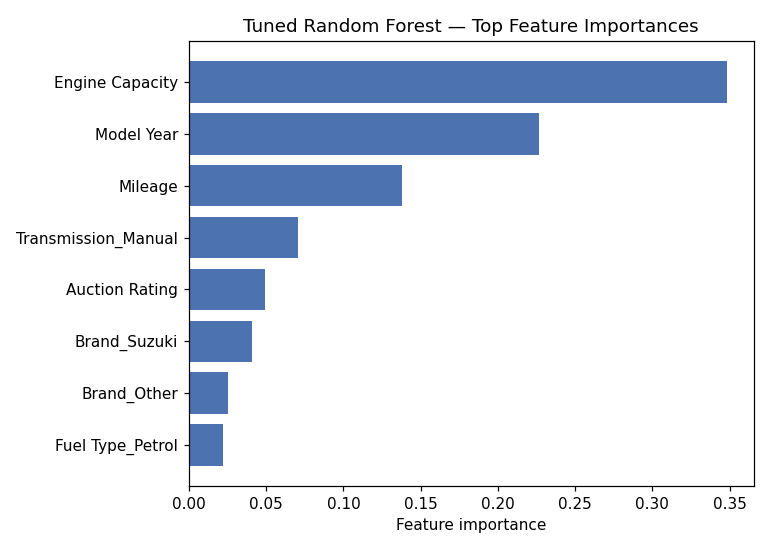

In [1]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 8 feature importances:")
print(importances.head(8).round(4))

top_n = importances.head(8)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_n.index[::-1], top_n.values[::-1], color="#4C72B0")
ax.set_xlabel("Feature importance")
ax.set_title("Tuned Random Forest \u2014 Top Feature Importances")
plt.tight_layout()
plt.show()

**Interpretation:** The five most influential features are **Engine Capacity**, **Model Year**, **Mileage**, **Transmission (Manual)**, and **Auction Rating** — together accounting for over 80% of the model's total importance. This lines up with intuition about used-car pricing (and mirrors how Lab 2's EDA and Lab 3's single Decision Tree would be expected to rank drivers of price): bigger engines and newer, lower-mileage, better-rated cars push a listing into the "Expensive" bracket, while an automatic transmission (the reference category, versus manual) is associated with higher prices, matching the fact that automatics dominate the pricier end of this market.

## 9. Final Model Selection

**Chosen final model: the tuned Random Forest** (`n_estimators=300, max_depth=None, min_samples_split=10`).

**Justification:** It is not just the model with the best training score — it is the model with the best *held-out test* F1 (0.894) and Recall (0.914) among the three, it also had the best cross-validated F1 of any configuration explored (0.893), and the default Random Forest's cross-validation results already showed it has much lower fold-to-fold variance than a single Decision Tree (std 0.0046 vs 0.0099), meaning its performance is more trustworthy on data it hasn't seen. The plain Decision Tree edges the *default* Random Forest on a couple of single-split metrics, but loses to the *tuned* Random Forest on every metric that was checked with cross-validation.

## 10. Kaggle Prediction/Submission

Generating predictions from the final model in a Kaggle-style submission file (Part 7, Task 16).

In [1]:
submission = pd.DataFrame({
    "CarID": X_test.index,
    "Predicted_Expensive": y_pred_tuned
})
submission.to_csv("submission.csv", index=False)
print(submission.head(10).to_string(index=False))
print(f"\nSaved {len(submission)} predictions to submission.csv")

 CarID  Predicted_Expensive
  7970                    1
  1583                    1
  6512                    0
 12796                    0
  4596                    0
 14083                    0
 10446                    0
 12718                    1
  3895                    1
  5580                    0

Saved 3019 predictions to submission.csv

## 11. Conclusion

I ultimately chose the **tuned Random Forest** (300 trees, unrestricted depth, `min_samples_split=10`) as my final model for predicting whether a car falls in the "Expensive" (top 25% by price) bracket. Compared to the Lab 3-style Decision Tree baseline, it improves F1-score from 0.883 to 0.894 and Recall from 0.891 to 0.914 on the held-out test set, and — more importantly — it is far more stable across cross-validation folds than a single tree, which matters more than a marginal single-split win. Its main limitations are that it is a "black box" relative to a single tree (harder to explain any one prediction, even though global feature importances are available), it was tuned over a deliberately small grid so a wider or randomized search could likely still find a slightly better configuration, and the "Expensive" label itself is an artificial threshold I imposed on a continuous price rather than a naturally binary outcome, which the original churn dataset would not have had. If I had more time, I would try gradient-boosted tree models (e.g. XGBoost or LightGBM), a wider hyperparameter search using `RandomizedSearchCV` or Bayesian optimization, and — since the classes here are imbalanced — techniques aimed directly at that imbalance such as class-weighting or SMOTE oversampling, to see whether Recall on the minority ("Expensive") class can be pushed higher without sacrificing precision.